# Fuel Consumption pridict with **Polynomial Regresion** and **Simple and Multiple Linear Regression** and **Random Forest Regressor**

## Import Libraries

In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures, LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

## Load fuel consumption file

In [4]:
co2 = pd.read_csv('FuelConsumption.csv')

In [5]:
co2.head()

,MODELYEAR,MAKE,MODEL,VEHICLECLASS,ENGINESIZE,CYLINDERS,TRANSMISSION,FUELTYPE,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
0,2014,ACURA,ILX,COMPACT,2.0,4,AS5,Z,9.9,6.7,8.5,33,196
1,2014,ACURA,ILX,COMPACT,2.4,4,M6,Z,11.2,7.7,9.6,29,221
2,2014,ACURA,ILX HYBRID,COMPACT,1.5,4,AV7,Z,6.0,5.8,5.9,48,136
3,2014,ACURA,MDX 4WD,SUV - SMALL,3.5,6,AS6,Z,12.7,9.1,11.1,25,255
4,2014,ACURA,RDX AWD,SUV - SMALL,3.5,6,AS6,Z,12.1,8.7,10.6,27,244


In [6]:
co2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067 entries, 0 to 1066
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   MODELYEAR                 1067 non-null   int64  
 1   MAKE                      1067 non-null   object 
 2   MODEL                     1067 non-null   object 
 3   VEHICLECLASS              1067 non-null   object 
 4   ENGINESIZE                1067 non-null   float64
 5   CYLINDERS                 1067 non-null   int64  
 6   TRANSMISSION              1067 non-null   object 
 7   FUELTYPE                  1067 non-null   object 
 8   FUELCONSUMPTION_CITY      1067 non-null   float64
 9   FUELCONSUMPTION_HWY       1067 non-null   float64
 10  FUELCONSUMPTION_COMB      1067 non-null   float64
 11  FUELCONSUMPTION_COMB_MPG  1067 non-null   int64  
 12  CO2EMISSIONS              1067 non-null   int64  
dtypes: float64(4), int64(4), object(5)
memory usage: 108.5+ KB


In [7]:
co2.describe()

,MODELYEAR,ENGINESIZE,CYLINDERS,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
count,1067.0,1067.000000,1067.000000,1067.000000,1067.000000,1067.000000,1067.000000,1067.000000
mean,2014.0,3.346298,5.794752,13.296532,9.474602,11.580881,26.441425,256.228679
std,0.0,1.415895,1.797447,4.101253,2.794510,3.485595,7.468702,63.372304
min,2014.0,1.000000,3.000000,4.600000,4.900000,4.700000,11.000000,108.000000
25%,2014.0,2.000000,4.000000,10.250000,7.500000,9.000000,21.000000,207.000000
50%,2014.0,3.400000,6.000000,12.600000,8.800000,10.900000,26.000000,251.000000
75%,2014.0,4.300000,8.000000,15.550000,10.850000,13.350000,31.000000,294.000000
max,2014.0,8.400000,12.000000,30.200000,20.500000,25.800000,60.000000,488.000000


In [8]:
co2.describe(include= 'object')

,MAKE,MODEL,VEHICLECLASS,TRANSMISSION,FUELTYPE
count,1067,1067,1067,1067,1067
unique,39,663,16,22,4
top,FORD,F150 FFV 4X4,MID-SIZE,A6,X
freq,90,8,178,222,514


In [9]:
label_encode = LabelEncoder()
fuel_type_labels = pd.DataFrame(label_encode.fit_transform(co2.FUELTYPE), columns= ['FUELTYPE'])
vehicle_class_labels = pd.DataFrame(label_encode.fit_transform(co2.VEHICLECLASS), columns= ['VEHICLECLASS'])
transmission_labels = pd.DataFrame(label_encode.fit_transform(co2.TRANSMISSION), columns= ['TRANSMISSION'])
new_labels_df = pd.concat((fuel_type_labels, vehicle_class_labels, transmission_labels), axis= 1)
new_labels_df.head()

,FUELTYPE,VEHICLECLASS,TRANSMISSION
0,3,0,10
1,3,0,20
2,3,0,17
3,3,11,11
4,3,11,11


In [10]:
new_labels_df.describe()

,FUELTYPE,VEHICLECLASS,TRANSMISSION
count,1067.000000,1067.000000,1067.000000
mean,2.269916,6.337395,9.670103
std,0.722374,5.095388,6.673143
min,0.000000,0.000000,0.000000
25%,2.000000,2.000000,2.000000
50%,2.000000,6.000000,11.000000
75%,3.000000,11.000000,13.000000
max,3.000000,15.000000,21.000000


In [11]:
new_co2_df = co2.drop(columns=['MODELYEAR', 'MAKE', 'MODEL', 'VEHICLECLASS', 'TRANSMISSION', 'FUELTYPE'], axis= 1)

In [12]:
new_co2_df.head()

,ENGINESIZE,CYLINDERS,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
0,2.0,4,9.9,6.7,8.5,33,196
1,2.4,4,11.2,7.7,9.6,29,221
2,1.5,4,6.0,5.8,5.9,48,136
3,3.5,6,12.7,9.1,11.1,25,255
4,3.5,6,12.1,8.7,10.6,27,244


In [13]:
new_co2_df = pd.concat((new_labels_df, new_co2_df), axis= 1)

In [14]:
new_co2_df.head()

,FUELTYPE,VEHICLECLASS,TRANSMISSION,ENGINESIZE,CYLINDERS,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
0,3,0,10,2.0,4,9.9,6.7,8.5,33,196
1,3,0,20,2.4,4,11.2,7.7,9.6,29,221
2,3,0,17,1.5,4,6.0,5.8,5.9,48,136
3,3,11,11,3.5,6,12.7,9.1,11.1,25,255
4,3,11,11,3.5,6,12.1,8.7,10.6,27,244


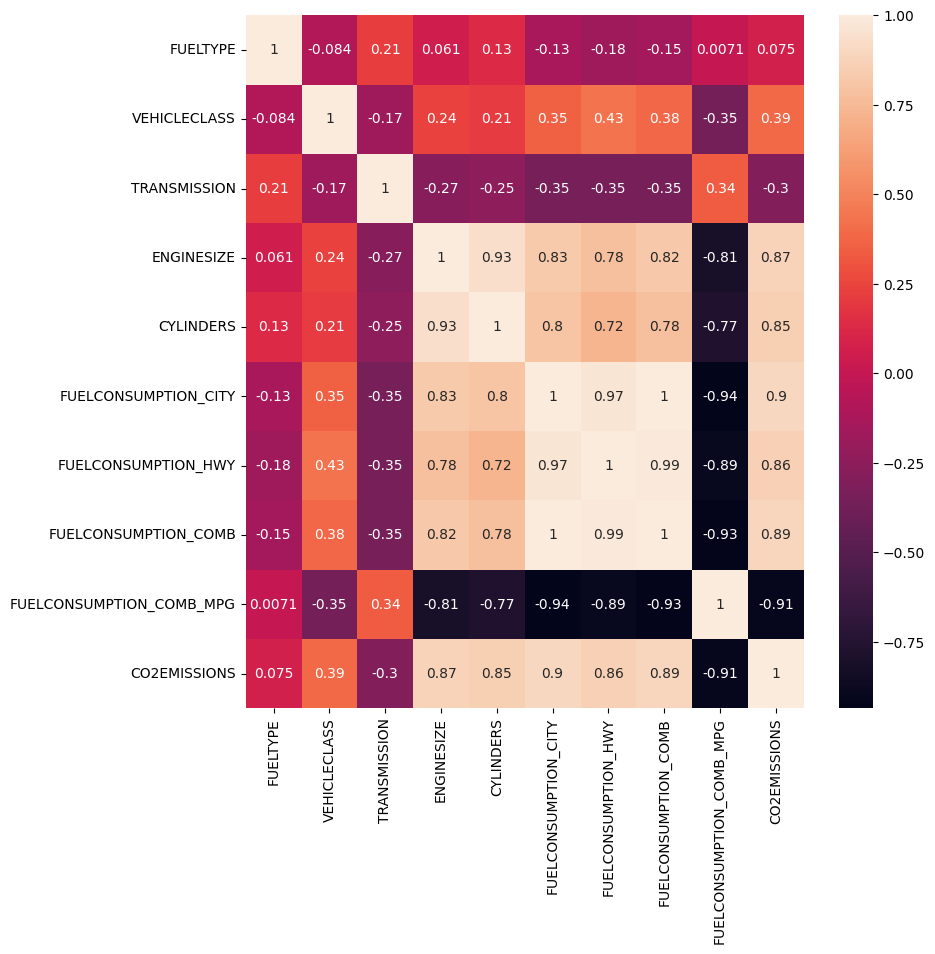

In [15]:
plt.figure(figsize= (9, 9))
sns.heatmap(new_co2_df.corr(), annot= True)
plt.show()

In [16]:
new_co2_df.corr(method= 'spearman')['CO2EMISSIONS'].sort_values(ascending= False)

,CO2EMISSIONS
CO2EMISSIONS,1.000000
FUELCONSUMPTION_COMB,0.953496
FUELCONSUMPTION_CITY,0.949859
FUELCONSUMPTION_HWY,0.936560
ENGINESIZE,0.889973
CYLINDERS,0.875330
VEHICLECLASS,0.393557
FUELTYPE,0.105436
TRANSMISSION,-0.290277
FUELCONSUMPTION_COMB_MPG,-0.952809


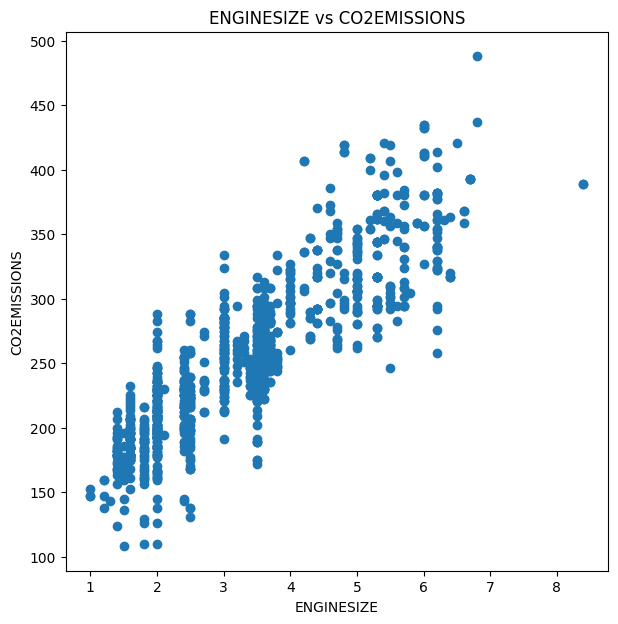

In [17]:
plt.figure(figsize= (7, 7))
plt.scatter(co2['ENGINESIZE'], co2['CO2EMISSIONS'])
plt.title('ENGINESIZE vs CO2EMISSIONS')
plt.xlabel('ENGINESIZE')
plt.ylabel('CO2EMISSIONS')
plt.show()

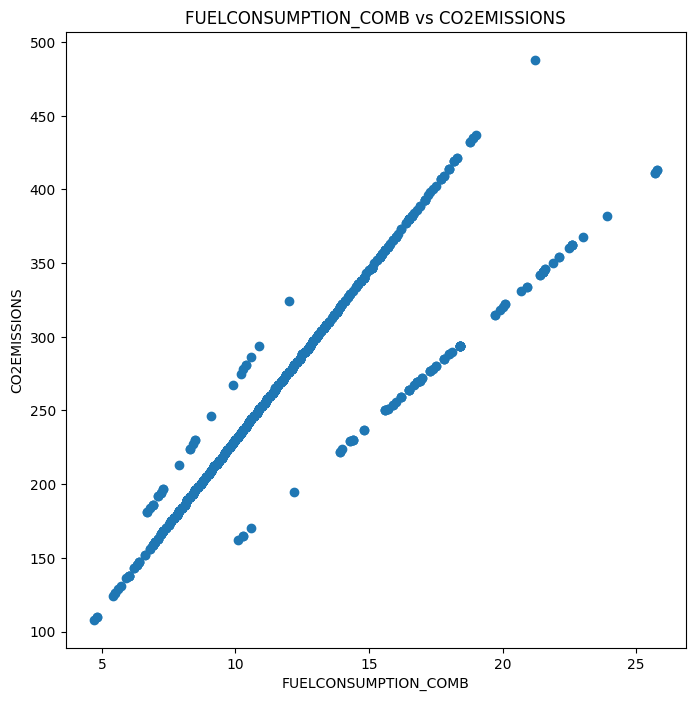

In [18]:
plt.figure(figsize= (8, 8))
plt.scatter(co2['FUELCONSUMPTION_COMB'], co2['CO2EMISSIONS'])
plt.title('FUELCONSUMPTION_COMB vs CO2EMISSIONS')
plt.xlabel('FUELCONSUMPTION_COMB')
plt.ylabel('CO2EMISSIONS')
plt.show()

## Simple Linear Regression Model
**Feature Selection:** The **`FUELCONSUMPTION_COMB`** feature was chosen for this model due to its **strong positive correlation** with the target, making it the most suitable predictor for a simple linear model.


In [19]:
X_simple = co2[['FUELCONSUMPTION_COMB']]
y_Simple = co2['CO2EMISSIONS']

## Train/Test Split
The data was split into training and testing sets after selecting **`FUELCONSUMPTION_COMB`** as the predictor variable.


In [20]:
X_train_simple, X_test_simple, y_train_simple, y_test_simple = train_test_split(X_simple, y_Simple, test_size= 0.2, random_state= 42)

## Training Simple Linear Model

In [21]:
simple_regr = LinearRegression()

In [22]:
simple_regr.fit(X_train_simple, y_train_simple)

LinearRegression()

In [23]:
print(f'Coef: {simple_regr.coef_[0]}\nIntercept: {simple_regr.intercept_}')

Coef: 16.180900781199195
Intercept: 69.10302617988444


In [24]:
y_train_hat = simple_regr.coef_[0] * X_train_simple[['FUELCONSUMPTION_COMB']] + simple_regr.intercept_
y_test_hat = simple_regr.coef_[0] * X_test_simple[['FUELCONSUMPTION_COMB']] + simple_regr.intercept_

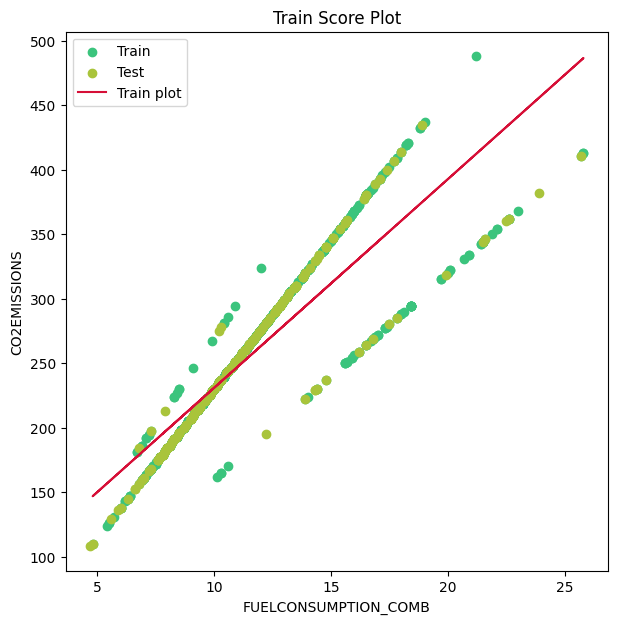

In [25]:
plt.figure(figsize= (7, 7))
plt.scatter(X_train_simple['FUELCONSUMPTION_COMB'], y_train_simple, c= '#3bc47d', label= 'Train')
plt.scatter(X_test_simple['FUELCONSUMPTION_COMB'], y_test_simple, c= '#a9c43b', label= 'Test')
plt.plot(X_train_simple['FUELCONSUMPTION_COMB'], y_train_hat, c='#d60f37', label= 'Train plot')
plt.title('Train Score Plot')
plt.xlabel('FUELCONSUMPTION_COMB')
plt.ylabel('CO2EMISSIONS')
plt.legend()
plt.show()

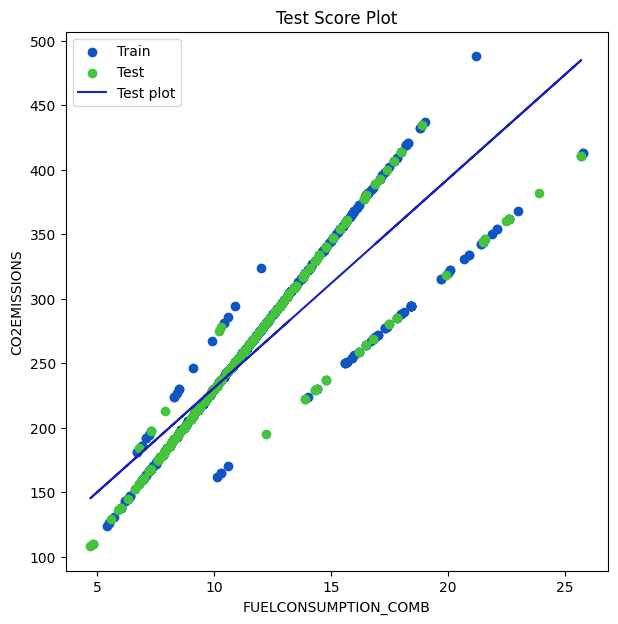

In [26]:
plt.figure(figsize= (7, 7))
plt.scatter(X_train_simple['FUELCONSUMPTION_COMB'], y_train_simple, c= '#1055c4', label= 'Train')
plt.scatter(X_test_simple['FUELCONSUMPTION_COMB'], y_test_simple, c= '#44c43b', label= 'Test')
plt.plot(X_test_simple['FUELCONSUMPTION_COMB'], y_test_hat, c= '#1a22b8', label= 'Test plot')
plt.title('Test Score Plot')
plt.xlabel('FUELCONSUMPTION_COMB')
plt.ylabel('CO2EMISSIONS')
plt.legend()
plt.show()

## Evaluate Model Performance (MSE, MAE, $R^2$)


In [27]:
y_hat = simple_regr.predict(X_test_simple)

In [28]:
print(f'Mean Squared Error: {mean_squared_error(y_test_simple, y_hat)}\nMean Absolute Error: {mean_absolute_error(y_test_simple, y_hat)}\nR2: {simple_regr.score(X_test_simple[['FUELCONSUMPTION_COMB']], y_test_simple)* 100:.2f}%\nTrain Score: {simple_regr.score(X_train_simple[['FUELCONSUMPTION_COMB']], y_train_simple)* 100:.2f}%')

Mean Squared Error: 797.4346310097206
Mean Absolute Error: 20.441911472549577
R2: 80.71%
Train Score: 79.27%


# Multiple Linear Regression

## Use the Features with the Highest Correlation


In [29]:
X_mult = new_co2_df[['FUELCONSUMPTION_COMB', 'FUELCONSUMPTION_CITY', 'FUELCONSUMPTION_HWY', 'ENGINESIZE', 'CYLINDERS', 'FUELCONSUMPTION_COMB_MPG']]
y_mult = new_co2_df['CO2EMISSIONS']

## Split Dataset into Train and Test Sets

In [30]:
X_train_mult, X_test_mult, y_train_mult, y_test_mult = train_test_split(X_mult, y_mult, test_size= 0.2, random_state= 42)

##  Training **Multiple Linear Regression**

In [31]:
mult_regr = LinearRegression()

In [32]:
mult_regr.fit(X_train_mult, y_train_mult)

LinearRegression()

In [33]:
print(f'Coefficients: {mult_regr.coef_}\nIntercept: {mult_regr.intercept_}')

Coefficients: [ 21.86697334 -13.00156667  -5.47215573   8.96115125   7.24023686
  -4.03446041]
Intercept: 262.5721608698736


## Evaluate Model Performance (MSE, MAE, $R^2$)


In [34]:
y_hat = mult_regr.predict(X_test_mult)

In [35]:
print(f'Mean squared Error: {mean_squared_error(y_test_mult, y_hat)}\nMean Absolute Error: {mean_absolute_error(y_test_mult, y_hat)}\nR2: {mult_regr.score(X_test_mult, y_test_mult) * 100:.2f}%\nTrain Score: {mult_regr.score(X_train_mult, y_train_mult) * 100:.2f}%')

Mean squared Error: 399.41868891442715
Mean Absolute Error: 12.90135933801832
R2: 90.34%
Train Score: 88.54%


# **Polynomial Regression**

## Comparing Linear and Polynomial Regression

First, the relationship between the feature and the target variable was modeled using **Linear Regression** as a baseline model.

Next, **Polynomial Regression** was applied to capture possible nonlinear patterns in the data. The performance of both models was then compared using evaluation metrics such as **MSE**, **MAE**, and **$R^2$ score**.
The polynomial features were created with `include_bias=False` because the linear regression model already includes an intercept term.


## Feature Selection

The **`ENGINESIZE`** feature was selected as the input variable because engine size is expected to have a meaningful effect on **CO2 emissions**. Larger engines generally consume more fuel and may produce higher emissions.

This feature was used to train and compare both **Linear Regression** and **Polynomial Regression** models.


In [36]:
X_poly_reg = co2[['ENGINESIZE']]
y_poly_reg = co2['CO2EMISSIONS']

## Train/Test Split
The data was split into training and testing sets after selecting **`ENGINESIZE`** as the predictor variable.


In [37]:
X_train_linear, X_test_linear, y_train_linear, y_test_linear = train_test_split(X_poly_reg, y_poly_reg, test_size= 0.2, random_state= 42)

## Data Visualization
A **Scatter Plot** is used to visualize the relationship between **`ENGINESIZE`** and **`CO2EMISSIONS`**. This plot helps us observe the distribution of data points and identify whether a linear or non-linear trend exists before training the models.


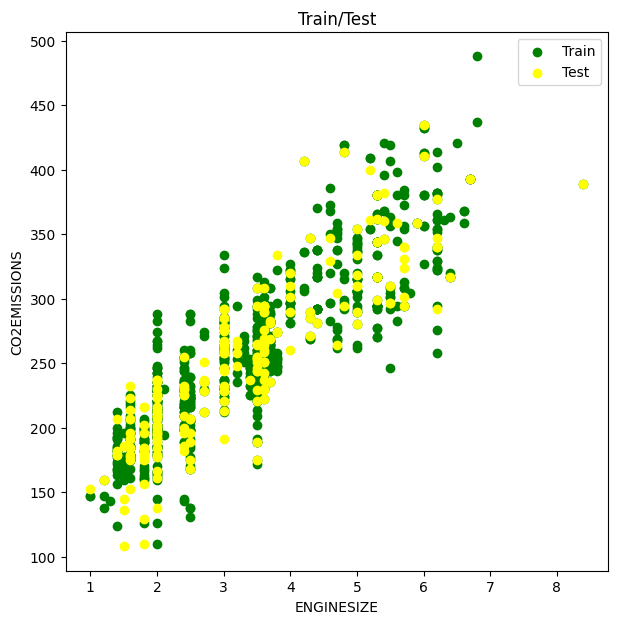

In [38]:
plt.figure(figsize= (7,7))
plt.scatter(X_train_linear, y_train_linear, c= 'green', label= 'Train')
plt.scatter(X_test_linear, y_test_linear, c= 'yellow', label= 'Test')
plt.title('Train/Test')
plt.xlabel('ENGINESIZE')
plt.ylabel('CO2EMISSIONS')
plt.legend()
plt.show()

## Training Linear Regression Model

The **`ENGINESIZE`** feature was used to train a **Linear Regression** model.  
This model helps us estimate **CO2 emissions** based on engine size and provides a simple baseline for comparison with more advanced models.


In [39]:
linear_regr = LinearRegression()

In [40]:
linear_regr.fit(X_train_linear, y_train_linear)

LinearRegression()

In [41]:
y_hat_linear = linear_regr.coef_[0] * X_test_linear + linear_regr.intercept_

## Scatter Plot with Regression Line

A **scatter plot** was created to visualize the relationship between **`ENGINESIZE`** and **`CO2EMISSIONS`**.  
The fitted linear regression line was then drawn on the same plot using the equation learned from the training data, making it easier to see how well the model matches the actual data points.


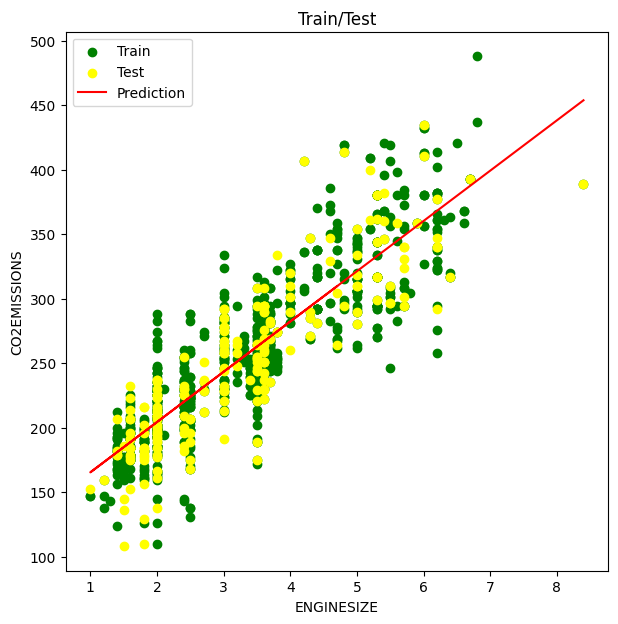

In [42]:
plt.figure(figsize= (7,7))
plt.scatter(X_train_linear, y_train_linear, c= 'green', label= 'Train')
plt.scatter(X_test_linear, y_test_linear, c= 'yellow', label= 'Test')
plt.plot(X_test_linear, y_hat_linear, c= 'red', label= 'Prediction')
plt.title('Train/Test')
plt.xlabel('ENGINESIZE')
plt.ylabel('CO2EMISSIONS')
plt.legend()
plt.show()

## Evaluate Model Performance (MSE, MAE, $R^2$)


In [43]:

print(f'Mean Squared Error: {mean_squared_error(y_test_linear, y_hat_linear)}\nMean Absolute Error: {mean_absolute_error(y_test_linear, y_hat_linear)}\nR2: {linear_regr.score(X_test_linear, y_test_linear) * 100:.2f}%\nTrain Score: {linear_regr.score(X_train_linear, y_train_linear) * 100:.2f}%')

Mean Squared Error: 985.9381692274999
Mean Absolute Error: 24.09725741170784
R2: 76.16%
Train Score: 76.44%


## Modeling with 2nd Degree Polynomial

### Train/Test Split & Transformation
To evaluate our model's performance on unseen data, we first split our dataset into **Train** and **Test** sets.

Next, to capture the non-linear relationship between **`ENGINESIZE`** and **`CO2EMISSIONS`**, we apply a **2nd-degree polynomial transformation** to the training features. This means for each input $x$ (Engine Size), we generate new features: $[x, x^2]$.

This transformation converts our linear model into a quadratic form:
$$y = \theta_0 + \theta_1 x + \theta_2 x^2$$

This allows the model to fit a curve (parabola) to the training data instead of a straight line, which should improve accuracy for this dataset.


In [66]:
X_train_linear, X_test_linear, y_train_linear, y_test_linear = train_test_split(X_poly_reg, y_poly_reg, test_size= 0.2, random_state= 42)

In [67]:
poly = PolynomialFeatures(degree= 2, include_bias= False)

In [68]:
X_train_poly= poly.fit_transform(X_train_linear)
X_test_poly = poly.fit_transform(X_test_linear)

In [69]:
print(f'{poly.get_feature_names_out()}\n\n{X_train_poly}')

['ENGINESIZE' 'ENGINESIZE^2']

[[ 1.4   1.96]
 [ 4.4  19.36]
 [ 3.    9.  ]
 ...
 [ 4.4  19.36]
 [ 1.8   3.24]
 [ 5.6  31.36]]


In [70]:
X_train_poly.shape

(853, 2)

In [71]:
poly_regr = LinearRegression()

In [72]:
poly_regr.fit(X_train_poly, y_train_linear)

LinearRegression()

In [73]:
print(f'Coefficient: {poly_regr.coef_}\nIntercept_: {poly_regr.intercept_}\n')

Coefficient: [47.42976379 -1.12705382]
Intercept_: 112.92021963451731



In [74]:
len(co2['ENGINESIZE'].unique())

45

In [75]:
co2['ENGINESIZE'].describe()

,ENGINESIZE
count,1067.000000
mean,3.346298
std,1.415895
min,1.000000
25%,2.000000
50%,3.400000
75%,4.300000
max,8.400000


In [76]:
XX = np.linspace(1, 8.4, 45)
XX

array([1.        , 1.16818182, 1.33636364, 1.50454545, 1.67272727,
       1.84090909, 2.00909091, 2.17727273, 2.34545455, 2.51363636,
       2.68181818, 2.85      , 3.01818182, 3.18636364, 3.35454545,
       3.52272727, 3.69090909, 3.85909091, 4.02727273, 4.19545455,
       4.36363636, 4.53181818, 4.7       , 4.86818182, 5.03636364,
       5.20454545, 5.37272727, 5.54090909, 5.70909091, 5.87727273,
       6.04545455, 6.21363636, 6.38181818, 6.55      , 6.71818182,
       6.88636364, 7.05454545, 7.22272727, 7.39090909, 7.55909091,
       7.72727273, 7.89545455, 8.06363636, 8.23181818, 8.4       ])

In [77]:
y_hat_poly = poly_regr.coef_[0] * XX + poly_regr.coef_[1] * XX ** 2 + poly_regr.intercept_

### Visualization

The scatter plot shows the original data points, while the red curve represents the predictions made by the 2nd-degree Polynomial Regression model.

The curved line allows us to visually examine how well the model fits the relationship between engine size and CO2 emissions.


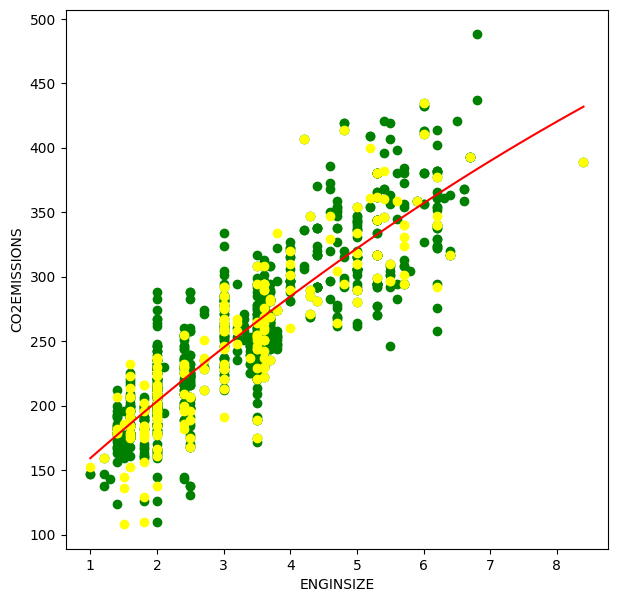

In [78]:
plt.figure(figsize= (7, 7))
plt.scatter(X_train_linear, y_train_linear, c= 'green', label= 'Train')
plt.scatter(X_test_linear, y_test_linear, c= 'yellow', label= 'Test')
plt.plot(XX, y_hat_poly, c= 'red')
plt.xlabel('ENGINSIZE')
plt.ylabel('CO2EMISSIONS')
plt.show()

### Prediction

After training the model, we use the transformed test data to generate predictions.

It is important to use the same polynomial transformer that was fitted on the training data.


In [79]:
y_predict_poly = poly_regr.predict(X_test_poly)

### Model Evaluation

We evaluate the Polynomial Regression model using the test set. The following metrics are used:

- **Mean Absolute Error (MAE):** Measures the average absolute difference between actual and predicted values.
- **Mean Squared Error (MSE):** Measures the average squared difference between actual and predicted values.
- **R² Score:** Measures how well the model explains the variation in the target variable.

Lower MAE and MSE values indicate better performance, while a higher $R^2$ score is preferred.


In [82]:
print(f'Mean Squared Error: {mean_squared_error(y_test_linear, y_predict_poly)}\nMean Absolute Error: {mean_absolute_error(y_test_linear, y_predict_poly)}\nR2: {poly_regr.score(X_test_poly, y_test_linear) * 100:.2f}%\nTrain Score: {poly_regr.score(X_train_poly, y_train_linear) * 100:.2f}%')

Mean Squared Error: 960.8705832028332
Mean Absolute Error: 23.915883545298716
R2: 76.76%
Train Score: 76.58%


### Comparison with Linear Regression

Finally, we compare the Polynomial Regression model with the Linear Regression model using the same test data and evaluation metrics.

This comparison helps us determine whether adding the $x^2$ term improves the model's ability to capture the relationship between `ENGINESIZE` and `CO2EMISSIONS`.
